In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [2]:
data = pd.read_csv("Official Website of National Center of Seismology.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1747 entries, 0 to 1746
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Origin Time  1747 non-null   object 
 1   Lat          1747 non-null   float64
 2   Long         1747 non-null   float64
 3   Depth        1747 non-null   float64
 4   Magnitude    1747 non-null   float64
 5   Region       1747 non-null   object 
 6   Location     1747 non-null   object 
 7   Details      1747 non-null   object 
dtypes: float64(4), object(4)
memory usage: 109.3+ KB


In [4]:
data.describe()

,Lat,Long,Depth,Magnitude
count,1747.000000,1747.000000,1747.000000,1747.000000
mean,28.251952,82.304282,36.943389,3.609330
std,7.988324,9.789891,52.195758,0.795642
min,0.150000,60.040000,1.000000,1.000000
25%,24.750000,73.400000,10.000000,2.900000
50%,28.980000,80.250000,10.000000,3.700000
75%,34.990000,92.640000,38.500000,4.200000
max,39.980000,99.900000,460.000000,6.400000


In [5]:
data.shape

(1747, 8)

In [6]:
df=data.head()
df

,Origin Time,Lat,Long,Depth,Magnitude,Region,Location,Details
0,2023-03-22 16:42:35 IST,28.66,77.03,5.0,2.7,West Delhi,"17km WNW of New Delhi, India",View
1,2023-03-22 19:35:42 IST,37.65,72.40,10.0,4.1,Tajikistan,"174km ENE of Fayzabad, Afghanistan",View
2,2023-03-23 01:37:46 IST,39.15,69.93,10.0,5.8,Tajikistan,"118km NE of Dushanbe, Tajikistan",View
3,2023-03-23 08:23:52 IST,39.31,69.89,10.0,4.6,Tajikistan,"126km NE of Dushanbe, Tajikistan",View
4,2023-03-23 11:03:41 IST,36.80,71.79,114.0,4.4,Tajikistan,"115km ESE of Fayzabad, Afghanistan",View


In [7]:
data.columns

Index(['Origin Time', 'Lat', 'Long', 'Depth', 'Magnitude', 'Region',
       'Location', 'Details'],
      dtype='object')

In [8]:
data.drop(['Origin Time', 'Details'], axis=1, inplace=True)

In [9]:
data.dropna(inplace=True)

In [10]:
# Encode categorical variables if any
data = pd.get_dummies(data)

In [11]:
data.isnull().sum()

Lat                                                   0
Long                                                  0
Depth                                                 0
Magnitude                                             0
Region_Afghanistan                                    0
                                                     ..
Location_9km ENE of Shillong, Meghalaya, India        0
Location_9km NNE of Ambikapur, Chhattisgarh, India    0
Location_9km SSE of Mokokchung, Nagaland, India       0
Location_9km W of Gurugram, Haryana, India            0
Location_9km WSW of Jaipur, Rajasthan, India          0
Length: 1843, dtype: int64

C:\python3.9\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


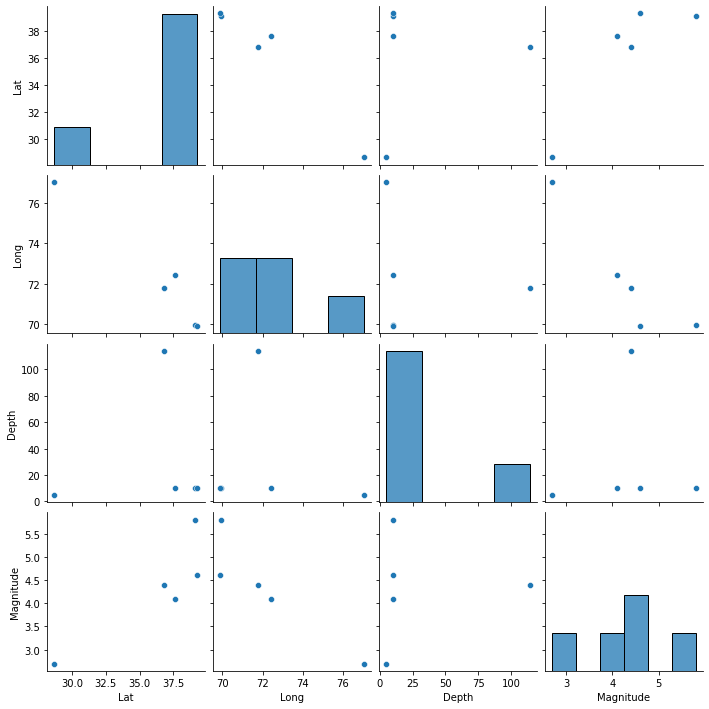

In [12]:
# # Data Visualization
# # Pairplot to visualize relationships between variables
sns.pairplot(df)
plt.show()



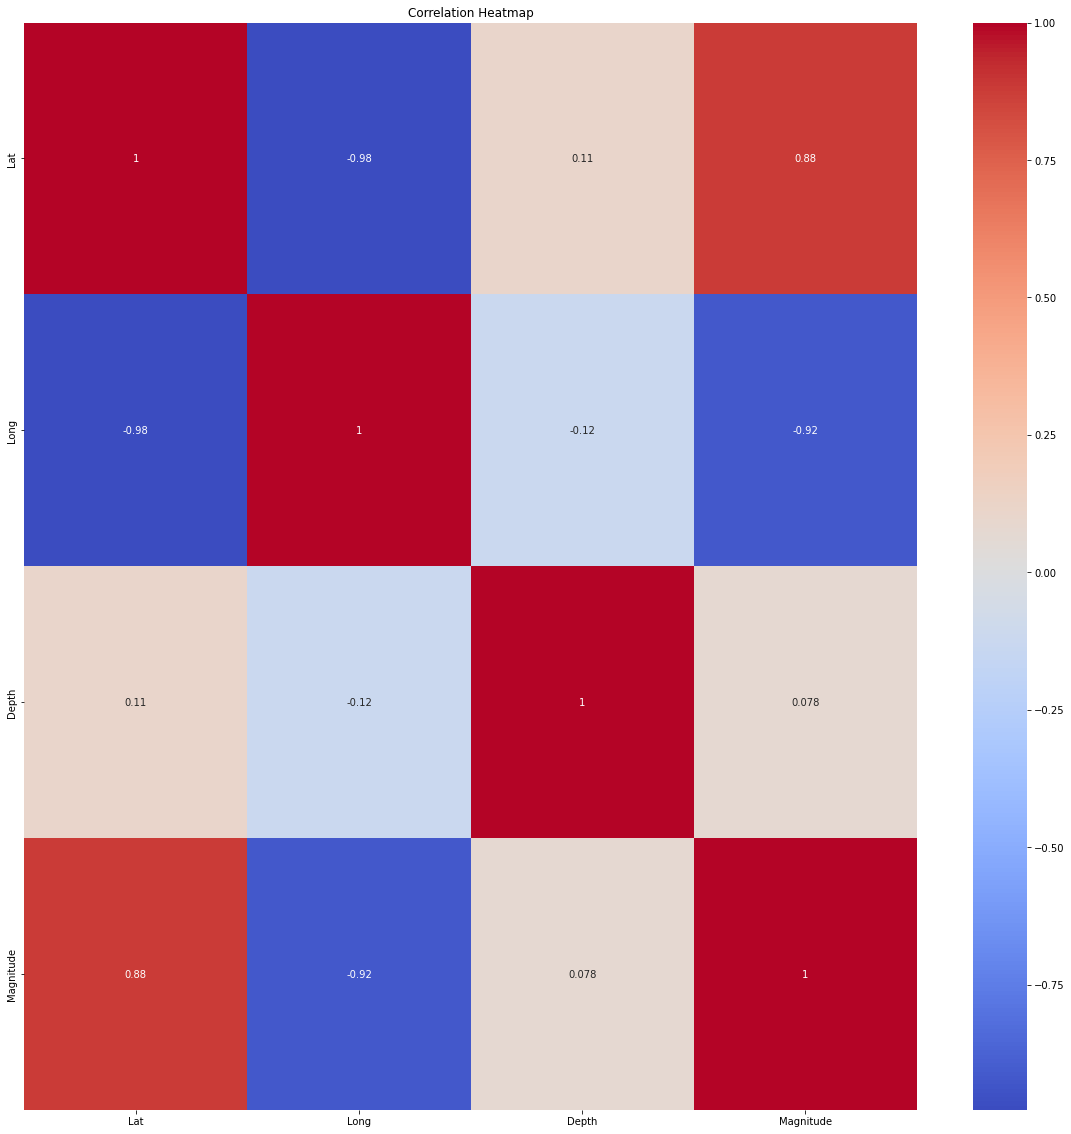

In [13]:
# Correlation heatmap
plt.figure(figsize=(20,20))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# Feature Selection
X = data.drop('Magnitude', axis=1)
y = data['Magnitude']

# Select top k features based on f_regression
selector = SelectKBest(score_func=f_regression, k=3)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

print("Selected Features:", selected_features)


Selected Features: Index(['Depth', 'Region_Afghanistan', 'Region_Tajikistan'], dtype='object')


In [15]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)


In [16]:
# Model Training and Evaluation
models = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    RandomForestRegressor(),
    GradientBoostingRegressor(),
    SVR(),
    KNeighborsRegressor()
]

mse_results = {}

for model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    model_name = model.__class__.__name__
    mse_results[model_name] = mse
    print(f"{model_name} - Mean Squared Error: {mse:.2f}")

# Identify the model with the lowest MSE
best_model = min(mse_results, key=mse_results.get)
print(f"\nBest performing model: {best_model} with MSE: {mse_results[best_model]:.2f}")


LinearRegression - Mean Squared Error: 0.41
Ridge - Mean Squared Error: 0.41
Lasso - Mean Squared Error: 0.45
RandomForestRegressor - Mean Squared Error: 0.37
GradientBoostingRegressor - Mean Squared Error: 0.35
SVR - Mean Squared Error: 0.40
KNeighborsRegressor - Mean Squared Error: 0.40

Best performing model: GradientBoostingRegressor with MSE: 0.35


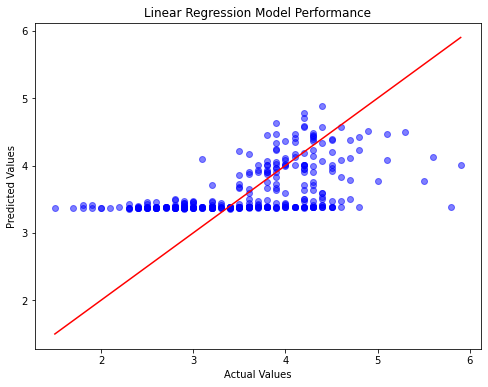

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title('Linear Regression Model Performance')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

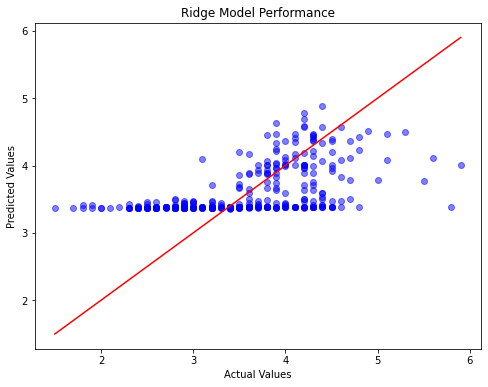

In [18]:
model = Ridge()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title('Ridge Model Performance')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

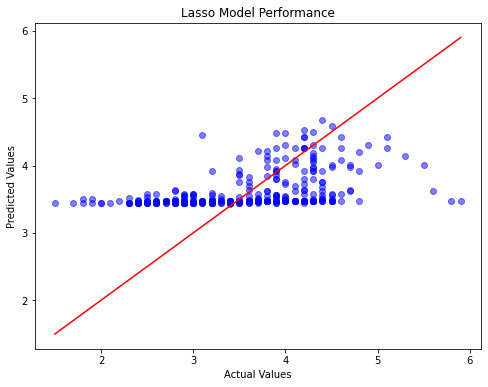

In [19]:
model = Lasso()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title('Lasso Model Performance')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

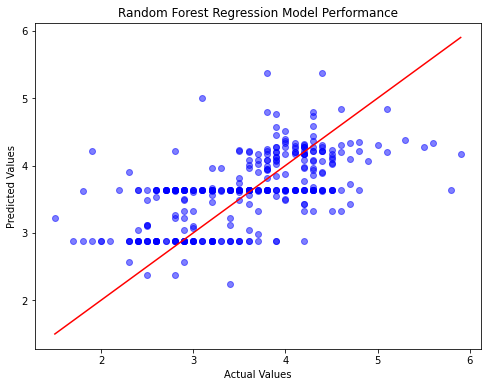

In [20]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title('Random Forest Regression Model Performance')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

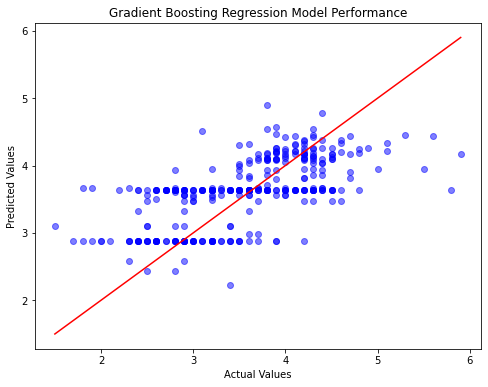

In [21]:
model = GradientBoostingRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title('Gradient Boosting Regression Model Performance')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

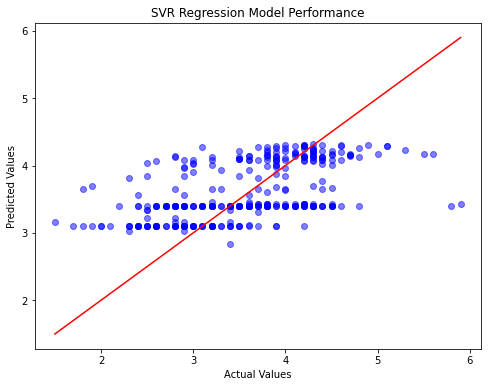

In [22]:
model = SVR()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title('SVR Regression Model Performance')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

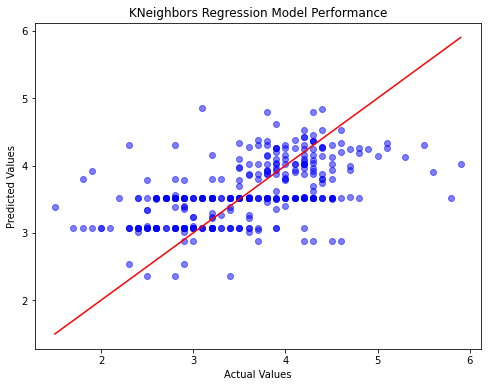

In [23]:
model = KNeighborsRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.title('KNeighbors Regression Model Performance')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

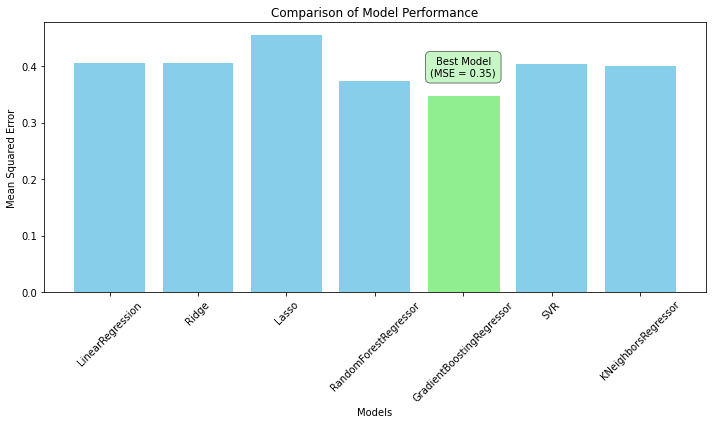

In [26]:
# Comparing Model Performance
model_names = [model.__class__.__name__ for model in models]
mse_scores = [mean_squared_error(y_test, model.predict(X_test)) for model in models]

# Find the index of the model with the lowest MSE
best_model_index = mse_scores.index(min(mse_scores))

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, mse_scores, color='skyblue')

# Highlight the best performing model
bars[best_model_index].set_color('lightgreen')

plt.xlabel('Models')
plt.ylabel('Mean Squared Error')
plt.title('Comparison of Model Performance')
plt.xticks(rotation=45)
plt.tight_layout()

# Annotate the best performing model
best_mse = mse_scores[best_model_index]
plt.annotate(f'Best Model\n(MSE = {best_mse:.2f})', 
             xy=(best_model_index, best_mse), 
             xytext=(0, 20), 
             textcoords='offset points', 
             ha='center', 
             fontsize=10, 
             bbox=dict(boxstyle='round,pad=0.5', 
                       fc='lightgreen', 
                       alpha=0.5))

plt.show()
